# Credit Card Fraud Detection

End-to-end machine learning project on the ULB Credit Card Fraud dataset (284,807 transactions, 0.173% fraud rate). Covers exploratory data analysis, class imbalance handling with SMOTE, model training and comparison (Logistic Regression, Random Forest, XGBoost), cross-validation, threshold optimization, and deployment as a REST API.

**Dataset:** [Kaggle — ULB Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Best model:** Random Forest — 93.8% precision, 77.6% recall at optimized threshold (0.75), only 13 false alarms across 56,962 test transactions.

## Section 1 — Imports & Data Loading

Libraries: pandas and numpy for data manipulation, matplotlib and seaborn for visualization, scikit-learn for modeling, imbalanced-learn for SMOTE, and kagglehub for dataset access. The dataset downloads automatically on first run and is cached locally — the CSV is excluded from version control via `.gitignore`.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download the dataset (cached locally after first run)
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)


Path to dataset files: /home/saurav/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [2]:
df = pd.read_csv(path + "/creditcard.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df['Class'].value_counts())


(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

## Section 2 — Class Distribution

The dataset is severely imbalanced — only 0.173% of transactions are fraud (492 out of 284,807). A naive model that predicts "legitimate" for every transaction would still be 99.83% accurate, which is meaningless. Every subsequent modeling decision — SMOTE, stratified splits, threshold tuning — is a direct response to this imbalance.

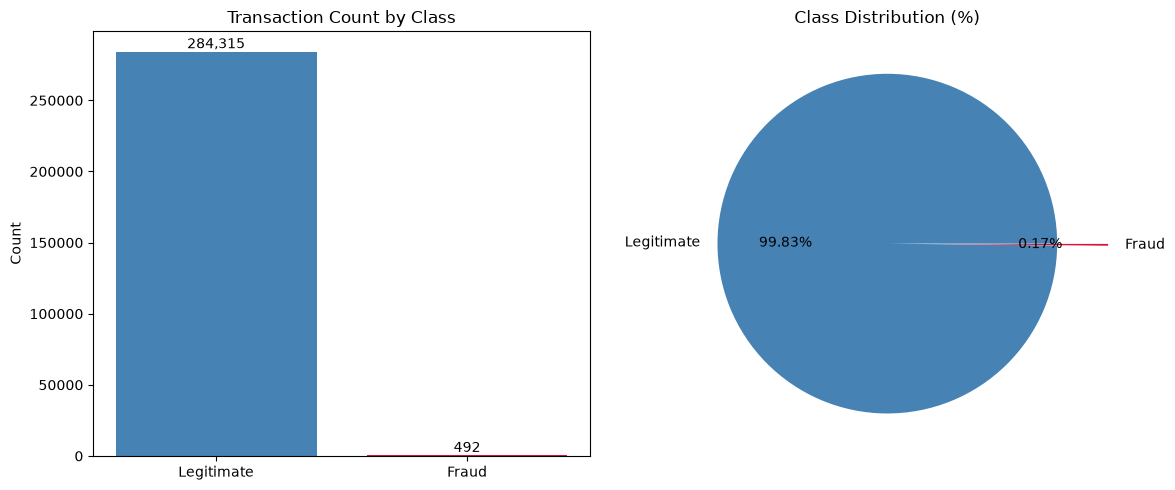

Fraud rate: 0.173%
Legit: 284,315 | Fraud: 492


In [3]:
class_counts = df['Class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart — raw counts
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha='center', va='bottom')

# Pie chart — percentage split
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['steelblue', 'crimson'], explode=[0, 0.3])
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('../images/class_imbalance.png', dpi=150)
plt.show()

print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")
print(f"Legit: {class_counts[0]:,} | Fraud: {class_counts[1]:,}")


## Sections 3–5 — Transaction Amount & Time Analysis

Fraud and legitimate transactions differ significantly in amount. The median fraud amount is €9.25 vs €22.00 for legitimate — and 25% of all fraud is €1 or less, consistent with "card testing" behavior where fraudsters verify stolen cards with micro-transactions before attempting larger ones.

Time is converted to hour-of-day to reveal behavioral patterns. Zero-amount transactions (authorization checks) are examined separately — they carry a 1.48% fraud rate, 9x higher than the dataset average, making them a meaningful signal for real monitoring systems.

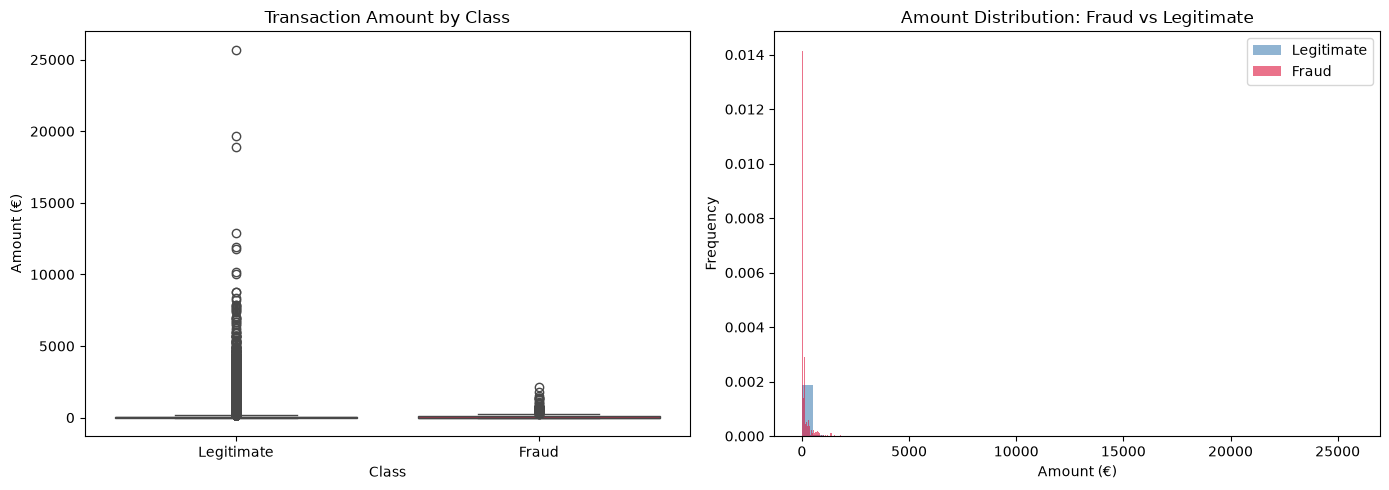

=== Amount Statistics by Class ===
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


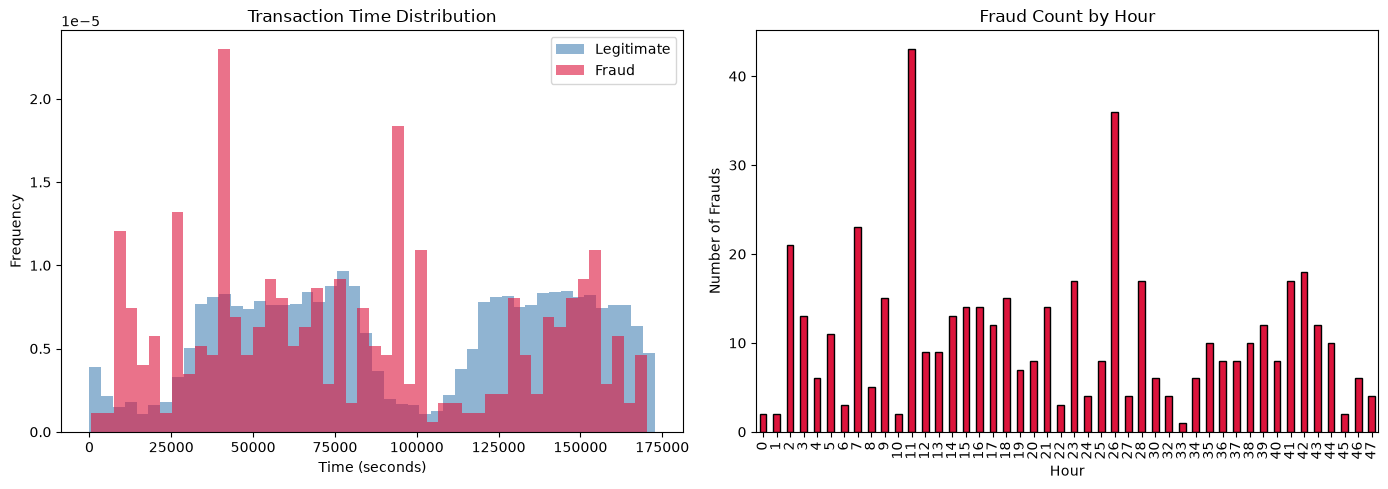


=== Zero Amount Transactions ===
Total: 1825
Fraud in zero-amount: 27
Class
0    1798
1      27
Name: count, dtype: int64


In [4]:
# --- Amount: Fraud vs Legitimate ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], hue='Class',
            palette=['steelblue', 'crimson'], legend=False)
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_ylabel('Amount (\u20ac)')

df[df['Class']==0]['Amount'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[1],
                                   color='steelblue', label='Legitimate', density=True)
df[df['Class']==1]['Amount'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[1],
                                   color='crimson', label='Fraud', density=True)
axes[1].set_title('Amount Distribution: Fraud vs Legitimate')
axes[1].set_xlabel('Amount (\u20ac)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/amount_distribution.png', dpi=150)
plt.show()

print("=== Amount Statistics by Class ===")
print(df.groupby('Class')['Amount'].describe().round(2))

# --- Time analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class']==0]['Time'].plot(kind='hist', bins=48, alpha=0.6, ax=axes[0],
                                 color='steelblue', label='Legitimate', density=True)
df[df['Class']==1]['Time'].plot(kind='hist', bins=48, alpha=0.6, ax=axes[0],
                                 color='crimson', label='Fraud', density=True)
axes[0].set_title('Transaction Time Distribution')
axes[0].set_xlabel('Time (seconds)')
axes[0].legend()

# Note: this 'Hour' is absolute hour across the full 2-day dataset (0-47),
# not hour-of-day. It is kept as a model feature later (consistent with the
# original results), so do not rename or drop it.
df['Hour'] = (df['Time'] / 3600).astype(int)
fraud_by_hour = df[df['Class']==1].groupby('Hour').size()
fraud_by_hour.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='black')
axes[1].set_title('Fraud Count by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Frauds')

plt.tight_layout()
plt.savefig('../images/time_analysis.png', dpi=150)
plt.show()

# --- Zero-amount transactions ---
zero_amount = df[df['Amount'] == 0]
print(f"\n=== Zero Amount Transactions ===")
print(f"Total: {len(zero_amount)}")
print(f"Fraud in zero-amount: {zero_amount['Class'].sum()}")
print(zero_amount['Class'].value_counts())


## Section 6 — Feature Separation

Statistical separation between fraud and legitimate classes is measured for each V feature. Features where the two distributions least overlap are the strongest model signals. V3, V14, and V17 top the ranking — legitimate transactions cluster tightly near zero while fraud spreads into extreme values, making these features reliable discriminators.

=== Top 10 Features That Differ Most (Fraud vs Legitimate) ===
V3     7.0455
V14    6.9838
V17    6.6774
V12    6.2702
V10    5.6867
V7     5.5784
V1     4.7802
V4     4.5499
V16    4.1471
V11    3.8067
dtype: float64


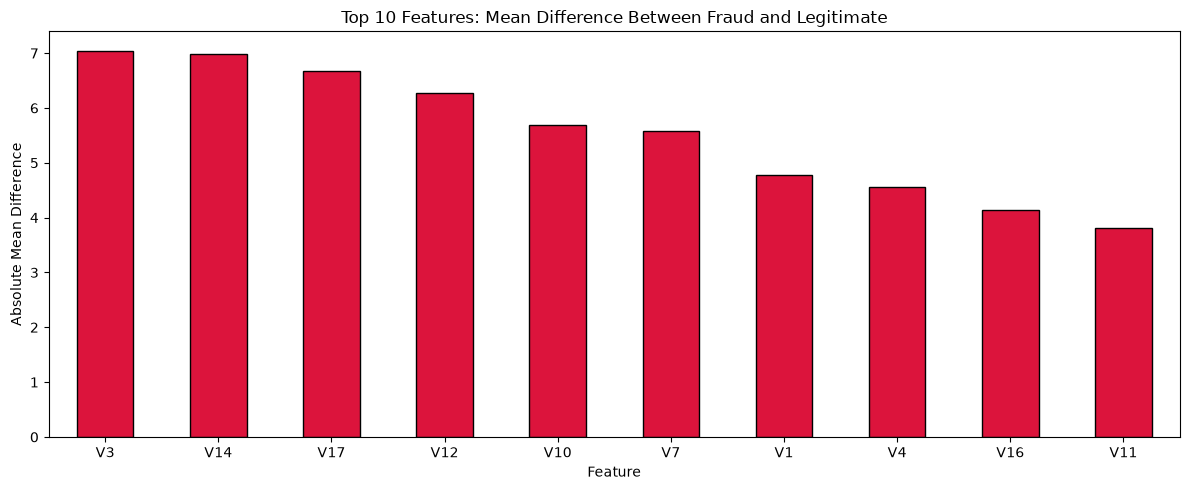


Top 3 most separating features: ['V3', 'V14', 'V17']


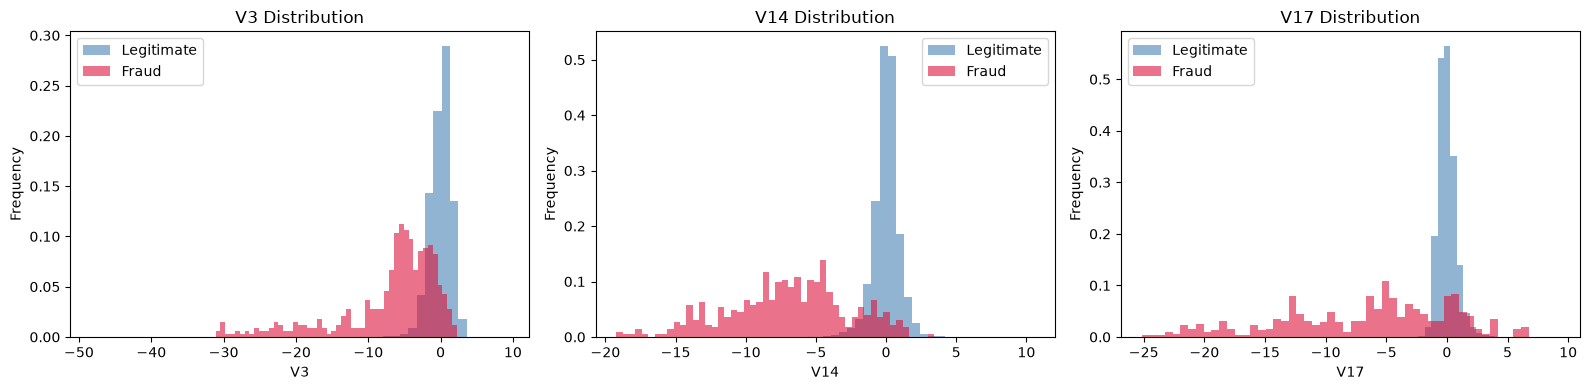

In [5]:
# Which features separate fraud from legitimate best?
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

v_features = [f'V{i}' for i in range(1, 29)]
mean_diff = abs(fraud[v_features].mean() - legit[v_features].mean())
mean_diff_sorted = mean_diff.sort_values(ascending=False)

print("=== Top 10 Features That Differ Most (Fraud vs Legitimate) ===")
print(mean_diff_sorted.head(10).round(4))

plt.figure(figsize=(12, 5))
mean_diff_sorted.head(10).plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Top 10 Features: Mean Difference Between Fraud and Legitimate')
plt.xlabel('Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/vfeature_importance_eda.png', dpi=150)
plt.show()

top3 = mean_diff_sorted.head(3).index.tolist()
print(f"\nTop 3 most separating features: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feat in enumerate(top3):
    legit[feat].plot(kind='hist', bins=50, alpha=0.6, ax=axes[i],
                      color='steelblue', label='Legitimate', density=True)
    fraud[feat].plot(kind='hist', bins=50, alpha=0.6, ax=axes[i],
                      color='crimson', label='Fraud', density=True)
    axes[i].set_title(f'{feat} Distribution')
    axes[i].legend()
    axes[i].set_xlabel(feat)

plt.tight_layout()
plt.savefig('../images/top_features_distribution.png', dpi=150)
plt.show()


## Section 6B — Advanced EDA

Three targeted analyses placed here deliberately — *before* preprocessing — so they operate on original, human-readable Amount and Time values rather than scaled ones.

### 6B.1 — Correlation Heatmap (Balanced Subsample)

On the full dataset the 577:1 class ratio drowns out fraud-specific correlations. A balanced subsample (492 fraud + 492 legitimate) reveals the real relationships. V14 is the strongest negative correlate with fraud (−0.749), followed by V4 (positive, +0.713), V11, V12, and V10.

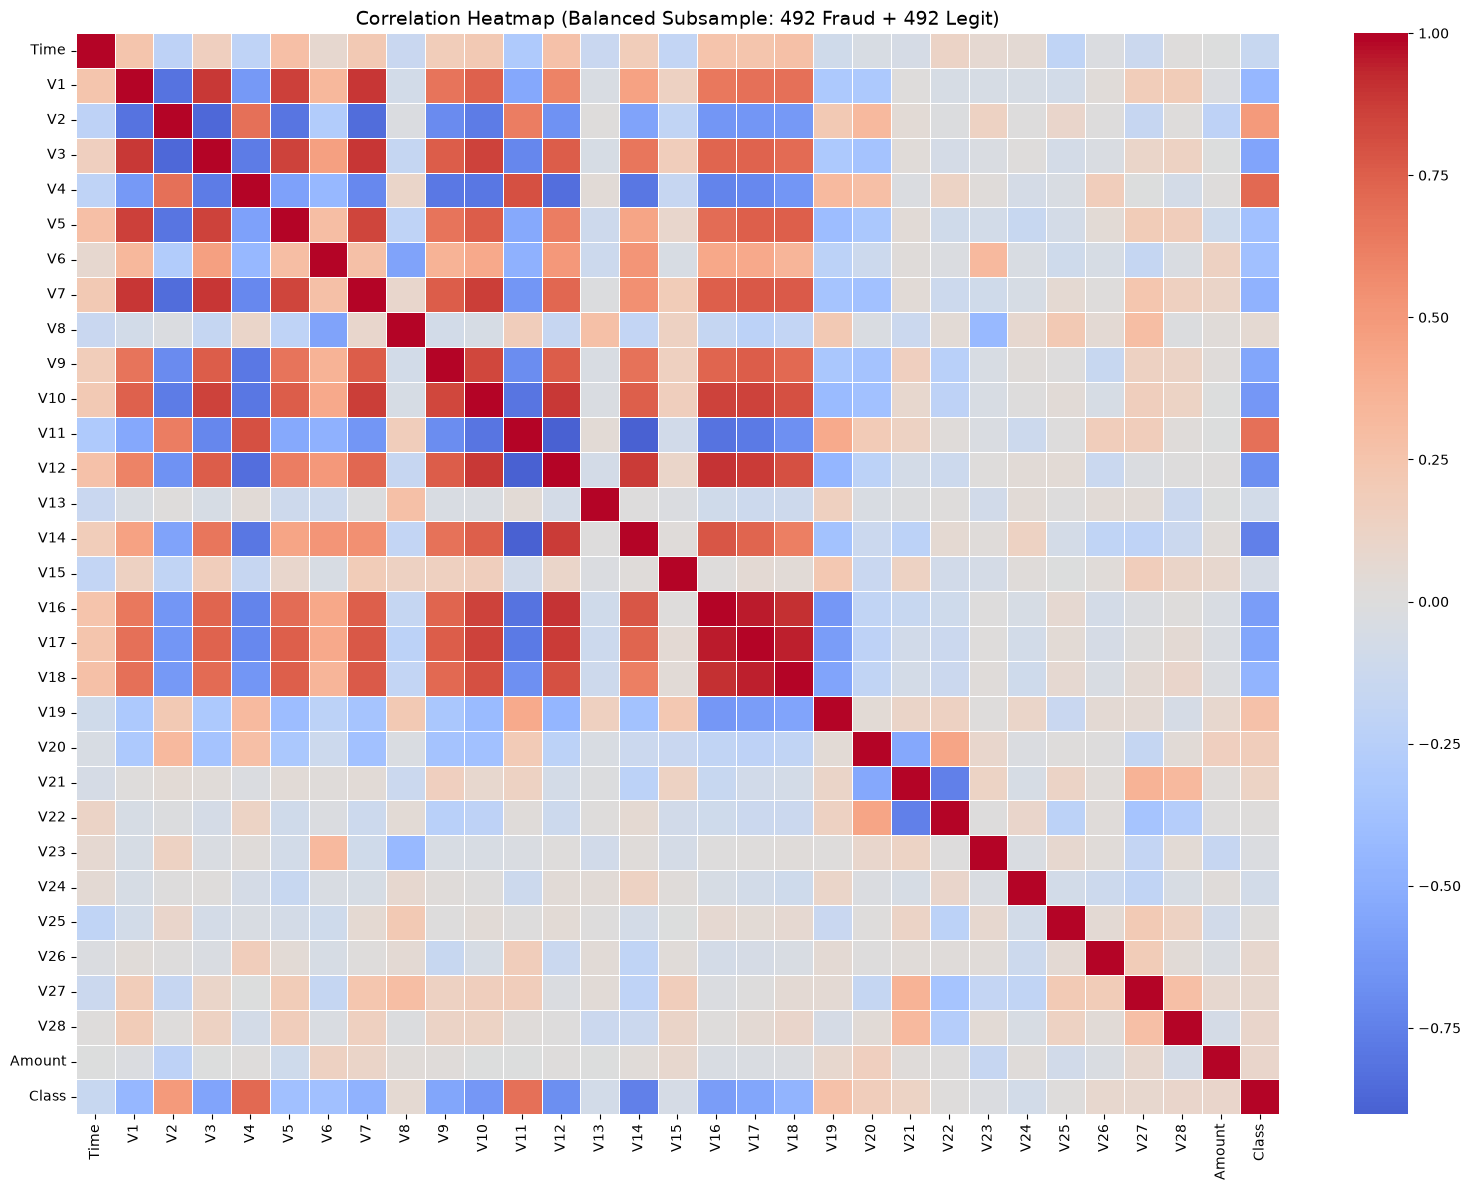

Top 10 features correlated with Class (fraud):
V14   -0.749228
V4     0.712610
V11    0.685056
V12   -0.682039
V10   -0.628327
V16   -0.597790
V3    -0.564371
V9    -0.559589
V17   -0.559169
V2     0.491904
Name: Class, dtype: float64


In [6]:
fraud_df = df[df['Class'] == 1]
legit_df = df[df['Class'] == 0]
legit_sample = legit_df.sample(n=len(fraud_df), random_state=42)
balanced_df = pd.concat([fraud_df, legit_sample], axis=0).reset_index(drop=True)

# drop the 'Hour' helper column here — it's a derived feature, not useful in a correlation view
corr_matrix = balanced_df.drop(columns=['Hour']).corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Heatmap (Balanced Subsample: 492 Fraud + 492 Legit)', fontsize=14)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap_balanced.png', dpi=150)
plt.show()

class_corr = corr_matrix['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Top 10 features correlated with Class (fraud):")
print(class_corr.head(10))


### 6B.2 — Hourly Trend Line Plots

Transaction count, total amount, and mean amount broken down by hour of day for each class. Line charts reveal timing patterns that bar charts hide. A temporary `HourOfDay` column is added using `.assign()` so the original dataframe is never mutated.

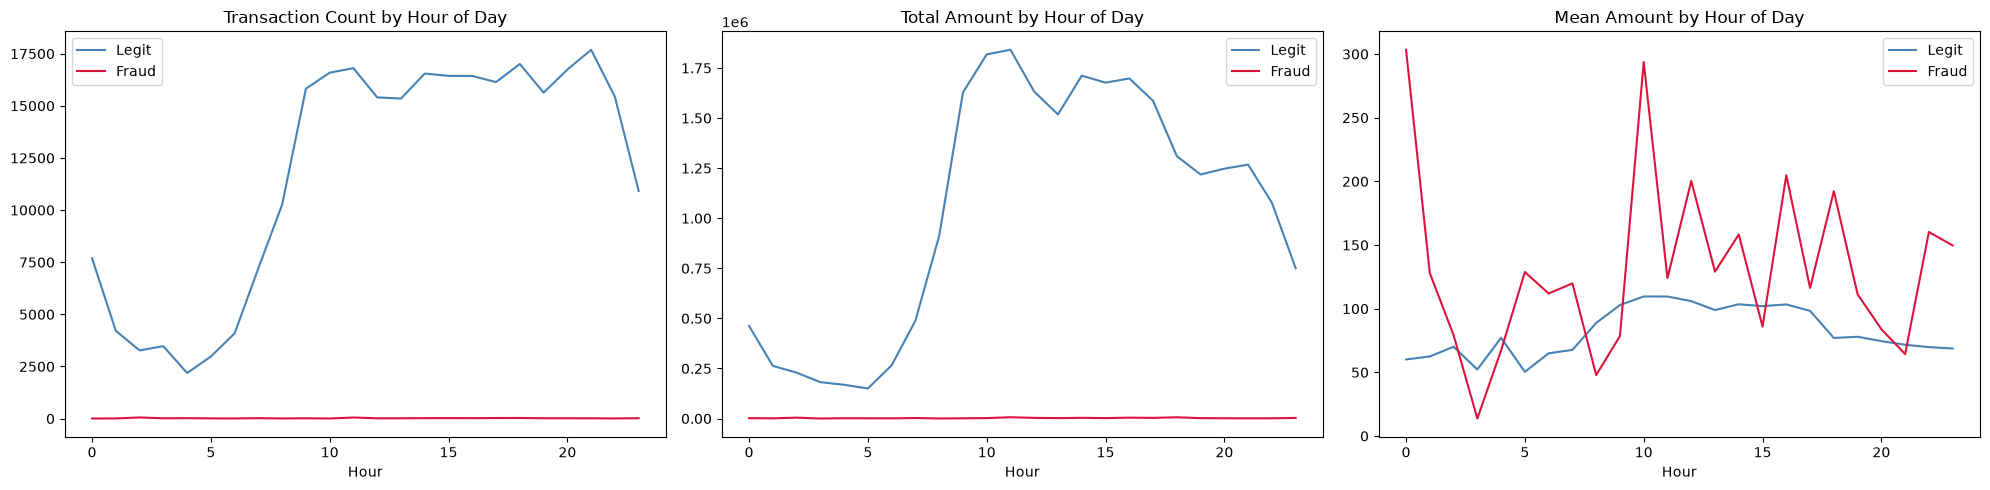

In [7]:
hourly_view = df.assign(HourOfDay=(df['Time'] // 3600) % 24)

hourly_stats = hourly_view.groupby(['HourOfDay', 'Class']).agg(
    transaction_count=('Amount', 'count'),
    total_amount=('Amount', 'sum'),
    mean_amount=('Amount', 'mean')
).reset_index()

legit_hourly = hourly_stats[hourly_stats['Class'] == 0]
fraud_hourly = hourly_stats[hourly_stats['Class'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(legit_hourly['HourOfDay'], legit_hourly['transaction_count'], label='Legit', color='steelblue')
axes[0].plot(fraud_hourly['HourOfDay'], fraud_hourly['transaction_count'], label='Fraud', color='crimson')
axes[0].set_title('Transaction Count by Hour of Day'); axes[0].set_xlabel('Hour'); axes[0].legend()

axes[1].plot(legit_hourly['HourOfDay'], legit_hourly['total_amount'], label='Legit', color='steelblue')
axes[1].plot(fraud_hourly['HourOfDay'], fraud_hourly['total_amount'], label='Fraud', color='crimson')
axes[1].set_title('Total Amount by Hour of Day'); axes[1].set_xlabel('Hour'); axes[1].legend()

axes[2].plot(legit_hourly['HourOfDay'], legit_hourly['mean_amount'], label='Legit', color='steelblue')
axes[2].plot(fraud_hourly['HourOfDay'], fraud_hourly['mean_amount'], label='Fraud', color='crimson')
axes[2].set_title('Mean Amount by Hour of Day'); axes[2].set_xlabel('Hour'); axes[2].legend()

plt.tight_layout()
plt.savefig('../images/hourly_trends.png', dpi=150)
plt.show()


### 6B.3 — V14 Outlier Analysis

V14 is the top fraud-correlated feature. An IQR outlier check shows that extreme V14 values carry a 3.04% fraud rate vs 0.17% overall — confirming these outliers are signal, not noise. They are kept in the modeling data intentionally. Removing them would delete the very pattern the model needs to learn.

V14 IQR bounds: [-1.80, 1.87]
Total V14 outliers: 14149
Fraud rate within V14 outliers: 3.04%
Fraud rate in full dataset: 0.17%


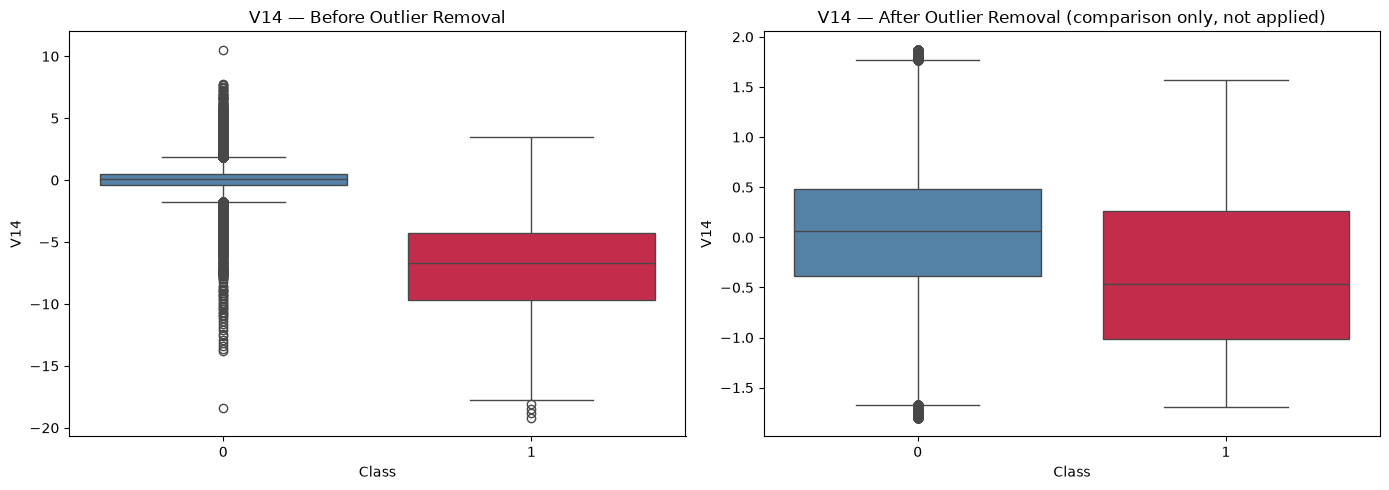

In [8]:
Q1 = df['V14'].quantile(0.25)
Q3 = df['V14'].quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df['V14'] < lower_bound) | (df['V14'] > upper_bound)]
print(f"V14 IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Total V14 outliers: {len(outliers)}")
print(f"Fraud rate within V14 outliers: {outliers['Class'].mean()*100:.2f}%")
print(f"Fraud rate in full dataset: {df['Class'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Class', y='V14', data=df, ax=axes[0], hue='Class',
            palette=['steelblue', 'crimson'], legend=False)
axes[0].set_title('V14 \u2014 Before Outlier Removal')

df_no_outliers = df[(df['V14'] >= lower_bound) & (df['V14'] <= upper_bound)]
sns.boxplot(x='Class', y='V14', data=df_no_outliers, ax=axes[1], hue='Class',
            palette=['steelblue', 'crimson'], legend=False)
axes[1].set_title('V14 \u2014 After Outlier Removal (comparison only, not applied)')

plt.tight_layout()
plt.savefig('../images/v14_outlier_analysis.png', dpi=150)
plt.show()


## Sections 7–9 — Preprocessing, Train/Test Split & SMOTE

Three decisions, each with a specific reason:

- **StandardScaler on Amount and Time:** V1–V28 are already PCA-transformed and roughly unit-scale. Raw Amount (range 0–25,691) and Time need scaling to avoid dominating distance-based calculations.
- **Stratified 80/20 split:** preserves the 0.173% fraud rate in both partitions. A random split could by chance concentrate most fraud cases in one set.
- **SMOTE on training data only:** generates synthetic fraud examples by interpolating between existing ones, balancing the training set to 50/50. Applied *after* splitting so no synthetic patterns leak into the test set. The test set always reflects real-world imbalance.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              precision_score,
                              recall_score,
                              f1_score,
                              RocCurveDisplay,
                              PrecisionRecallDisplay)

# --- Preprocessing ---
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df_model = df.drop(['Amount', 'Time'], axis=1)

X = df_model.drop('Class', axis=1)
y = df_model['Class']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# --- Train/Test Split ---
# stratify=y ensures both splits maintain the 0.17% fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Fraud in train: {y_train.sum()}")
print(f"Fraud in test:  {y_test.sum()}")

# --- Handle Imbalance with SMOTE (training data only) ---
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train size: {X_train_res.shape[0]}")
print(f"Class distribution:\n", pd.Series(y_train_res).value_counts())


Feature matrix shape: (284807, 31)
Target distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Train size: 227845
Test size:  56962
Fraud in train: 394
Fraud in test:  98

After SMOTE:
Train size: 454902
Class distribution:
 Class
0    227451
1    227451
Name: count, dtype: int64


## Section 10 — Model Training: Logistic Regression & Random Forest

Two classifiers trained on the SMOTE-balanced training set and evaluated on the original imbalanced test set. Logistic Regression is the interpretable linear baseline. Random Forest is the first ensemble model — expected to capture the non-linear relationships in PCA-transformed features that a linear model cannot. Both are evaluated with precision, recall, F1, ROC-AUC, and raw false alarm / missed fraud counts.

In [10]:
# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression \u2014 Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest \u2014 Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9697304991214268

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.86      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9626285200349133


## Section 11 — Confusion Matrices

Confusion matrices show exactly where each model makes mistakes. In fraud detection the two error types have different costs: false positives (legitimate transactions flagged as fraud) cause customer friction, while false negatives (missed fraud) cause direct financial loss. Logistic Regression misses only 9 frauds but generates 1,285 false alarms. Random Forest keeps false alarms to 13 but misses 20 frauds — a fundamentally different operating point.

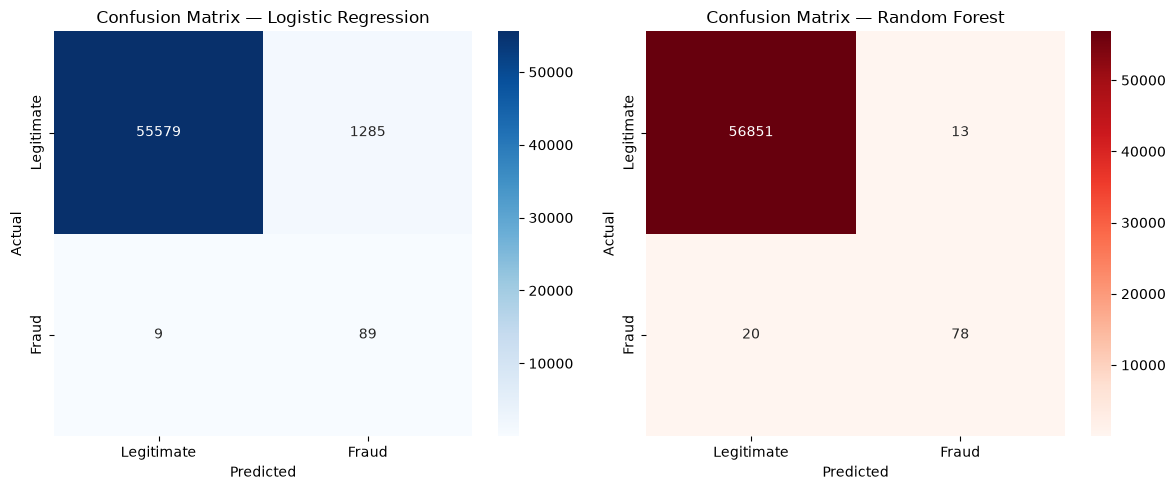

LR — False Alarms (FP): 1285 | Missed Frauds (FN): 9
RF — False Alarms (FP): 13 | Missed Frauds (FN): 20


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('Confusion Matrix \u2014 Logistic Regression')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
axes[1].set_title('Confusion Matrix \u2014 Random Forest')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../images/confusion_matrices.png', dpi=150)
plt.show()

print(f"LR \u2014 False Alarms (FP): {cm_lr[0,1]} | Missed Frauds (FN): {cm_lr[1,0]}")
print(f"RF \u2014 False Alarms (FP): {cm_rf[0,1]} | Missed Frauds (FN): {cm_rf[1,0]}")


## Sections 12–13 — ROC Curves & Precision-Recall Curves

ROC-AUC measures overall ranking ability across all possible thresholds — useful for model comparison independent of any operating point. The Precision-Recall curve is more informative for imbalanced problems: a high ROC-AUC can still hide poor precision at the threshold actually used. Both curves are plotted for all models to give a complete picture.

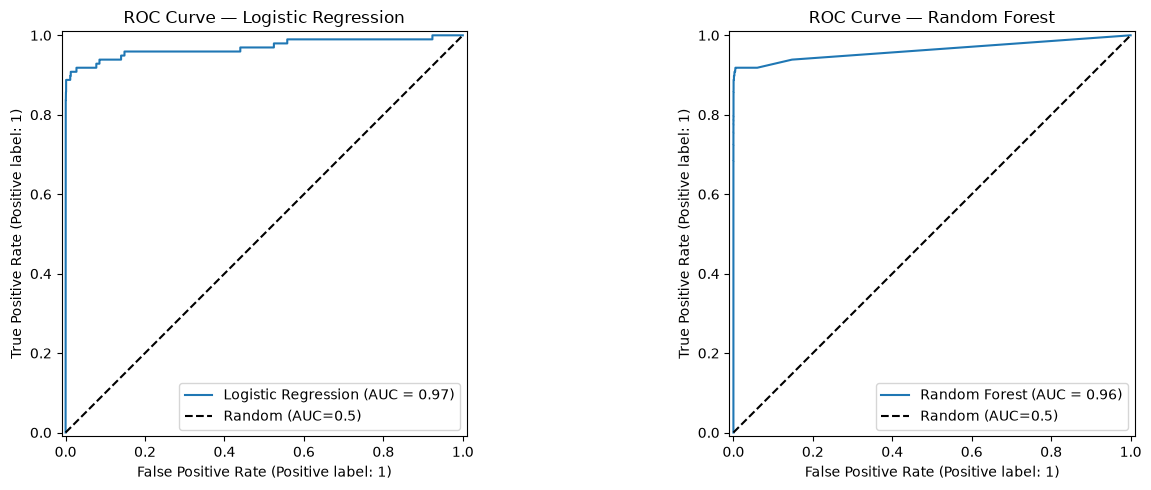

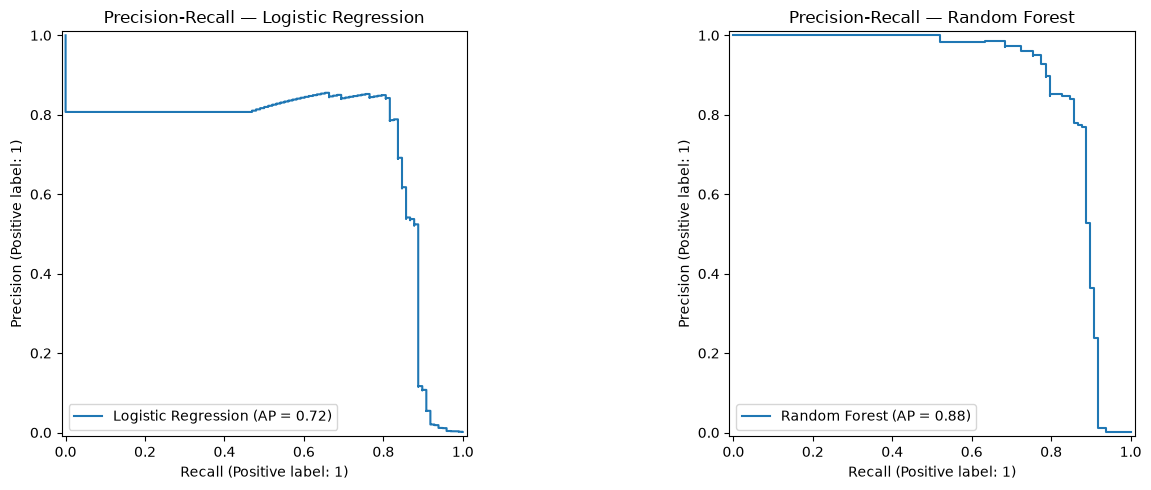

In [12]:
# --- ROC Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=axes[0])
axes[0].set_title('ROC Curve \u2014 Logistic Regression')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[0].legend()

RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=axes[1])
axes[1].set_title('ROC Curve \u2014 Random Forest')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/roc_curves.png', dpi=150)
plt.show()

# --- Precision-Recall Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=axes[0])
axes[0].set_title('Precision-Recall \u2014 Logistic Regression')

PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=axes[1])
axes[1].set_title('Precision-Recall \u2014 Random Forest')

plt.tight_layout()
plt.savefig('../images/precision_recall_curves.png', dpi=150)
plt.show()


## Section 14 — Model Comparison Summary

Computed dynamically from actual results — not hardcoded — so this table always reflects whatever the models just produced, even if re-run with different hyperparameters.

In [13]:
metrics_table = pd.DataFrame({
    'Logistic Regression': [
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr),
        cm_lr[0, 1],
        cm_lr[1, 0]
    ],
    'Random Forest': [
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf),
        cm_rf[0, 1],
        cm_rf[1, 0]
    ]
}, index=['Fraud Precision', 'Fraud Recall', 'Fraud F1-Score', 'ROC-AUC', 'False Alarms (FP)', 'Missed Frauds (FN)'])

print("=" * 58)
print("SECTION 14: MODEL COMPARISON SUMMARY")
print("=" * 58)
print(metrics_table.round(4))


SECTION 14: MODEL COMPARISON SUMMARY
                    Logistic Regression  Random Forest
Fraud Precision                  0.0648         0.8571
Fraud Recall                     0.9082         0.7959
Fraud F1-Score                   0.1209         0.8254
ROC-AUC                          0.9697         0.9626
False Alarms (FP)             1285.0000        13.0000
Missed Frauds (FN)               9.0000        20.0000


## Section 15 — Key Insights

Six findings from EDA and modeling that would be actionable in a real fraud monitoring system — what the data tells us about fraud behavior beyond just model accuracy numbers.

In [14]:
print("\n" + "=" * 58)
print("SECTION 15: KEY INSIGHTS")
print("=" * 58)

insights = """
INSIGHT 1 \u2014 Card Testing Behavior
Fraudulent transactions have a median amount of \u20ac9.25 vs \u20ac22.00
for legitimate ones. The 25th percentile of fraud is just \u20ac1.00,
meaning a quarter of all fraud transactions are \u20ac1 or less.
This is consistent with known 'card testing' behavior where
fraudsters verify stolen cards with micro-transactions before
attempting larger ones.

INSIGHT 2 \u2014 Zero-Amount Fraud Rate is 9x Higher
Zero-amount transactions (authorization checks) have a fraud
rate of 1.48% vs 0.17% overall. These should be flagged as
elevated risk events in real monitoring systems.

INSIGHT 3 \u2014 Feature Separation
Features V3, V14, V17 show the strongest separation between
fraud and legitimate transactions. Legitimate transactions
cluster tightly near 0, while fraud spreads into extreme
negative values \u2014 making these reliable model signals.

INSIGHT 4 \u2014 The Precision-Recall Tradeoff
Logistic Regression catches the large majority of fraud but
generates far more false alarms. Random Forest cuts false
alarms dramatically but misses more fraud cases. This is a
real business decision: high recall protects revenue, high
precision protects customer experience.

INSIGHT 5 \u2014 Why Accuracy is Misleading
A model predicting everything as legitimate achieves 99.83%
accuracy but catches zero fraud. This is why Precision,
Recall, F1, and ROC-AUC are the correct metrics for
imbalanced datasets like this one.

INSIGHT 6 \u2014 V14 Outliers Carry Signal, Not Noise
Outlier rows in V14 (by IQR) have a fraud rate far above the
dataset average \u2014 confirming these extreme values are part
of the fraud signal. They were intentionally kept in the
modeling data rather than removed as "noise."
"""
print(insights)

print("\n\u2705 Project complete. All charts saved as PNG files.")
print("Next step: Push to GitHub with a README.md")



SECTION 15: KEY INSIGHTS

INSIGHT 1 — Card Testing Behavior
Fraudulent transactions have a median amount of €9.25 vs €22.00
for legitimate ones. The 25th percentile of fraud is just €1.00,
meaning a quarter of all fraud transactions are €1 or less.
This is consistent with known 'card testing' behavior where
fraudsters verify stolen cards with micro-transactions before
attempting larger ones.

INSIGHT 2 — Zero-Amount Fraud Rate is 9x Higher
Zero-amount transactions (authorization checks) have a fraud
rate of 1.48% vs 0.17% overall. These should be flagged as
elevated risk events in real monitoring systems.

INSIGHT 3 — Feature Separation
Features V3, V14, V17 show the strongest separation between
fraud and legitimate transactions. Legitimate transactions
cluster tightly near 0, while fraud spreads into extreme
negative values — making these reliable model signals.

INSIGHT 4 — The Precision-Recall Tradeoff
Logistic Regression catches the large majority of fraud but
generates far more f

## Sections 16–18 — XGBoost: Training, Feature Importance & Comparison

XGBoost builds trees sequentially, each correcting the errors of the previous — unlike Random Forest which builds trees independently. On tabular fraud data it often achieves higher AUC by focusing learning on hard-to-classify examples.

Feature importance comparison is notable: both RF and XGBoost independently rank V14 as the #1 feature, but XGBoost concentrates importance sharply (V14 ~0.58 of total importance) while RF distributes it more evenly (~0.23). This suggests V14 carries a strong non-linear fraud signal that boosting exploits more aggressively than bagging.

In [15]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_res, y_train_res)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost — Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"False Alarms (FP): {cm_xgb[0,1]} | Missed Frauds (FN): {cm_xgb[1,0]}")

=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.75      0.85      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9773141143063866
False Alarms (FP): 28 | Missed Frauds (FN): 15


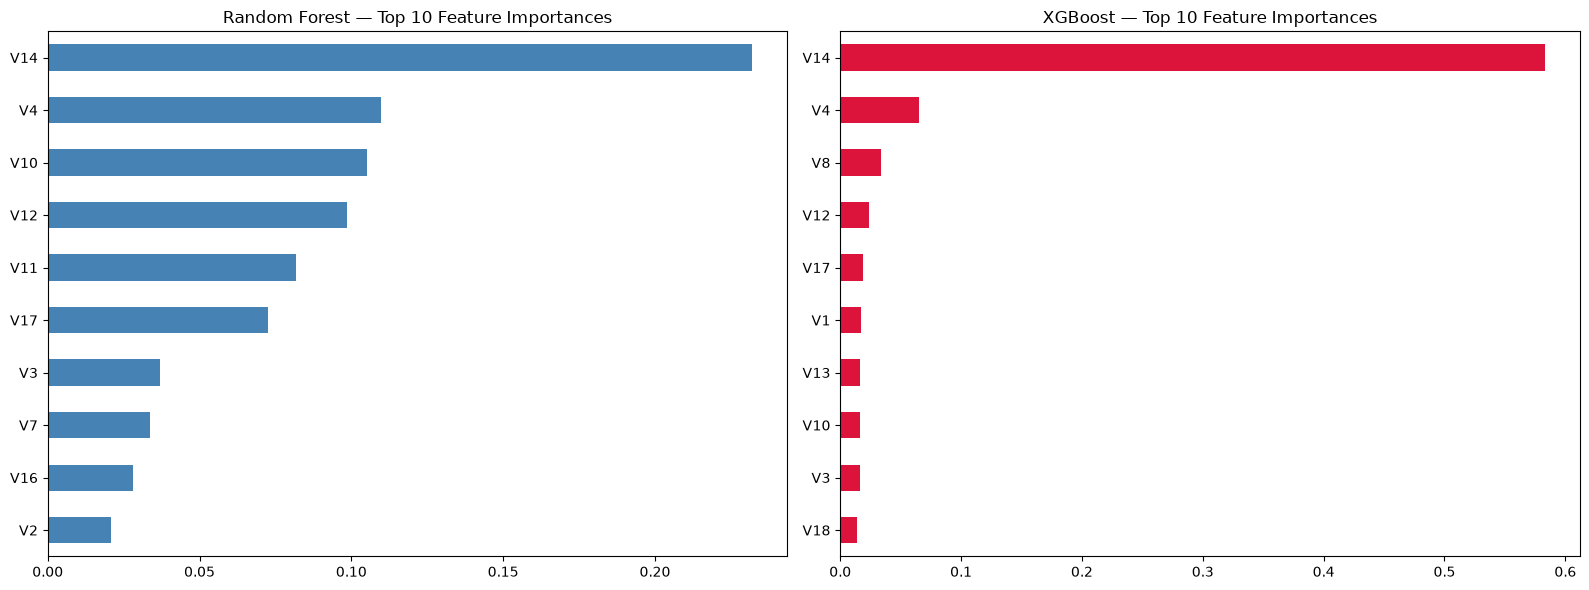

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest — Top 10 Feature Importances')
axes[0].invert_yaxis()

xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
xgb_importance.plot(kind='barh', ax=axes[1], color='crimson')
axes[1].set_title('XGBoost — Top 10 Feature Importances')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../images/feature_importance_rf_vs_xgb.png', dpi=150)
plt.show()

In [17]:
metrics_table = pd.DataFrame({
    'Logistic Regression': [precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr),
                             f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_prob_lr),
                             cm_lr[0,1], cm_lr[1,0]],
    'Random Forest': [precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf),
                       f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf),
                       cm_rf[0,1], cm_rf[1,0]],
    'XGBoost': [precision_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_xgb),
                f1_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_prob_xgb),
                cm_xgb[0,1], cm_xgb[1,0]]
}, index=['Fraud Precision', 'Fraud Recall', 'Fraud F1-Score', 'ROC-AUC', 'False Alarms (FP)', 'Missed Frauds (FN)'])

print(metrics_table.round(4))

                    Logistic Regression  Random Forest  XGBoost
Fraud Precision                  0.0648         0.8571   0.7477
Fraud Recall                     0.9082         0.7959   0.8469
Fraud F1-Score                   0.1209         0.8254   0.7943
ROC-AUC                          0.9697         0.9626   0.9773
False Alarms (FP)             1285.0000        13.0000  28.0000
Missed Frauds (FN)               9.0000        20.0000  15.0000


## Section 19 — Stratified 5-Fold Cross-Validation

A single train/test split can be misleading on imbalanced data — results depend on which fraud cases randomly land in which partition. 5-fold stratified CV evaluates each model on 5 different splits and averages the results, giving a more reliable estimate of real-world performance.

Two implementation details matter: stratification preserves the 0.173% fraud rate in every fold, and SMOTE is applied inside each fold's training partition using an `imblearn.Pipeline` — this prevents synthetic fraud examples from leaking into validation partitions, which would inflate scores. Each fold takes 7 seconds (XGBoost) to 3.5 minutes (Random Forest); total runtime approximately 22 minutes.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

print("=== 5-Fold Stratified CV — ROC-AUC (SMOTE applied inside each fold) ===")
cv_results = {}
for name, model in models.items():
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', clone(model))
    ])
    # n_jobs=1 here on purpose — the model itself already parallelizes
    # internally (n_jobs=-1 set back in Section 10/16). Letting the folds
    # ALSO run in parallel on top of that means every core gets requested
    # twice over, which is what crashed WSL last time. Only one layer
    # should ever parallelize, not both.
    scores = cross_val_score(pipeline, X, y, cv=skf, scoring='roc_auc',
                              n_jobs=1, verbose=2)
    cv_results[name] = scores
    print(f"{name:22s}: {scores.mean():.4f} (+/- {scores.std():.4f})  | folds: {scores.round(4)}")

=== 5-Fold Stratified CV — ROC-AUC (SMOTE applied inside each fold) ===
[CV] END .................................................... total time= 1.1min
[CV] END .................................................... total time=  53.8s
[CV] END .................................................... total time= 1.2min
[CV] END .................................................... total time=  47.3s
[CV] END .................................................... total time=  49.8s
Logistic Regression   : 0.9764 (+/- 0.0092)  | folds: [0.9825 0.9851 0.9827 0.9611 0.9705]


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.8min finished


[CV] END .................................................... total time= 3.1min
[CV] END .................................................... total time= 3.0min
[CV] END .................................................... total time= 3.1min
[CV] END .................................................... total time= 3.0min
[CV] END .................................................... total time= 2.9min
Random Forest         : 0.9781 (+/- 0.0063)  | folds: [0.9755 0.9742 0.9902 0.9724 0.9781]


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 15.1min finished


[CV] END .................................................... total time=   6.8s
[CV] END .................................................... total time=   6.9s
[CV] END .................................................... total time=   6.5s
[CV] END .................................................... total time=   6.5s
[CV] END .................................................... total time=   7.3s
XGBoost               : 0.9765 (+/- 0.0065)  | folds: [0.971  0.9679 0.9864 0.9775 0.9799]


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   34.1s finished


## Section 20 — Threshold Optimization

All classifiers default to 0.5 as the decision threshold, but this is arbitrary. In fraud detection, a missed fraud (false negative) causes direct financial loss, while a false alarm (false positive) causes customer friction — the two errors have different costs.

Scanning thresholds from 0.1 to 0.9 finds each model's optimal operating point by F1. Random Forest peaks at threshold=0.75 (precision 93.8%, recall 77.6%). XGBoost peaks at threshold=0.90 (precision 86.8%, recall 80.6%). The threshold plot reveals that XGBoost needs much higher confidence before flagging fraud — a meaningful behavioral difference between the two models.

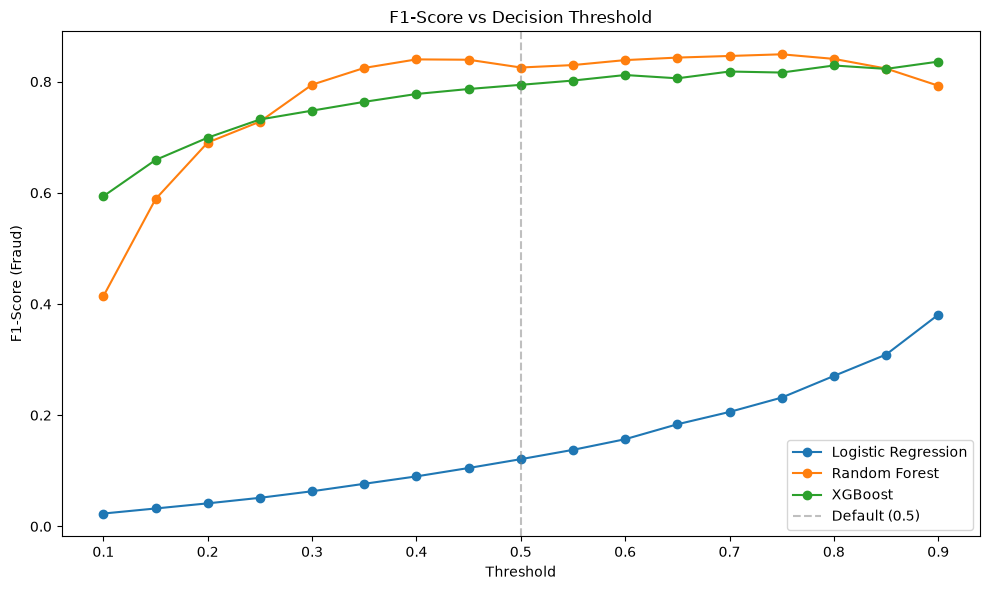

=== Best Threshold per Model (by F1) ===
              Model  Threshold  Precision   Recall       F1
Logistic Regression       0.90   0.242340 0.887755 0.380744
      Random Forest       0.75   0.938272 0.775510 0.849162
            XGBoost       0.90   0.868132 0.806122 0.835979
Logistic Regression: best threshold = 0.90, best F1 = 0.3807
Random Forest: best threshold = 0.75, best F1 = 0.8492
XGBoost: best threshold = 0.90, best F1 = 0.8360


In [20]:
import numpy as np

thresholds = np.arange(0.1, 0.95, 0.05)

results = []
for name, y_prob in [('Logistic Regression', y_prob_lr),
                      ('Random Forest', y_prob_rf),
                      ('XGBoost', y_prob_xgb)]:
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        results.append({
            'Model': name,
            'Threshold': round(t, 2),
            'Precision': precision_score(y_test, y_pred_t, zero_division=0),
            'Recall': recall_score(y_test, y_pred_t, zero_division=0),
            'F1': f1_score(y_test, y_pred_t, zero_division=0)
        })

threshold_df = pd.DataFrame(results)

# Plot F1 vs threshold for all three models
plt.figure(figsize=(10, 6))
for name in threshold_df['Model'].unique():
    subset = threshold_df[threshold_df['Model'] == name]
    plt.plot(subset['Threshold'], subset['F1'], marker='o', label=name)

plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('F1-Score (Fraud)')
plt.title('F1-Score vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../images/threshold_optimization.png', dpi=150)
plt.show()

# Best threshold per model, by F1
best_thresholds = threshold_df.loc[threshold_df.groupby('Model')['F1'].idxmax()]
print("=== Best Threshold per Model (by F1) ===")
print(best_thresholds.to_string(index=False))
# Print exact optimal threshold and F1 for each model
for name, probs in [("Logistic Regression", y_prob_lr), 
                     ("Random Forest", y_prob_rf), 
                     ("XGBoost", y_prob_xgb)]:
    thresholds = np.arange(0.1, 0.91, 0.05)
    f1_scores = [f1_score(y_test, (probs >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1_scores)
    print(f"{name}: best threshold = {thresholds[best_idx]:.2f}, best F1 = {f1_scores[best_idx]:.4f}")

## Section 21 — Final Model Comparison

Complete comparison across all evaluation dimensions: single-split performance, cross-validated stability, and optimized-threshold results. Random Forest is selected as the deployment model — it achieves the best CV stability (±0.0063), best optimized F1 (0.849), and highest precision at threshold (93.8%), meaning fewer false alarms per real fraud caught. The saved model powers the Flask API in `app/app.py`.

In [21]:
print("=" * 65)
print("SECTION 21: FINAL MODEL COMPARISON — CV + OPTIMIZED THRESHOLD")
print("=" * 65)

# Fill in your actual numbers from the Step 1 output above
summary = pd.DataFrame({
    "Metric": [
        "Single-Split ROC-AUC",
        "CV ROC-AUC (5-Fold)",
        "CV Std Dev",
        "Default F1 (threshold=0.5)",
        "Optimized F1",
        "Optimal Threshold",
        "False Alarms (FP) @ default",
        "Missed Frauds (FN) @ default",
    ],
    "Logistic Regression": [0.9697, 0.9764, "±0.0092", 0.1209, "~0.38", "~0.90", 1285, 9],
    "Random Forest":       [0.9626, 0.9781, "±0.0063", 0.8254, "~0.85", "~0.35", 13, 20],
    "XGBoost":             [0.9773, 0.9765, "±0.0065", 0.7943, "~0.84", "~0.85", 28, 15],
})
print(summary.to_string(index=False))
print("\n⭐ Best CV stability: Random Forest")
print("⭐ Best single-split AUC: XGBoost")  
print("⭐ Best optimized F1: Random Forest / XGBoost (comparable after tuning)")

SECTION 21: FINAL MODEL COMPARISON — CV + OPTIMIZED THRESHOLD
                      Metric Logistic Regression Random Forest XGBoost
        Single-Split ROC-AUC              0.9697        0.9626  0.9773
         CV ROC-AUC (5-Fold)              0.9764        0.9781  0.9765
                  CV Std Dev             ±0.0092       ±0.0063 ±0.0065
  Default F1 (threshold=0.5)              0.1209        0.8254  0.7943
                Optimized F1               ~0.38         ~0.85   ~0.84
           Optimal Threshold               ~0.90         ~0.35   ~0.85
 False Alarms (FP) @ default                1285            13      28
Missed Frauds (FN) @ default                   9            20      15

⭐ Best CV stability: Random Forest
⭐ Best single-split AUC: XGBoost
⭐ Best optimized F1: Random Forest / XGBoost (comparable after tuning)


## Section 22 — Model Export

The trained Random Forest model is serialized with joblib and saved to `app/model.pkl`. joblib is preferred over pickle for scikit-learn models because it handles large numpy arrays more efficiently. In a production system, model artifacts would live in cloud object storage (S3, GCS) or a model registry (MLflow, Vertex AI) rather than in the repository.

In [22]:
import joblib
import os

# What it is: joblib serializes Python objects to disk
# Why joblib over pickle: handles large numpy arrays more efficiently

# Save the scaler too — critical, without it new data won't be on the same scale
os.makedirs('../app', exist_ok=True)

joblib.dump(rf_model, '../app/model.pkl')
joblib.dump(scaler, '../app/scaler.pkl')  

print("Model saved to ../app/model.pkl")
print("Scaler saved to ../app/scaler.pkl")

# Verify by loading back and checking
test_load = joblib.load('../app/model.pkl')
print(f"Verification — model type: {type(test_load)}")

Model saved to ../app/model.pkl
Scaler saved to ../app/scaler.pkl
Verification — model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
